This notebook is where I made most of the various plots, including the bootsraps and covariance matrices and whatnot.

In [1]:
# load some base packages
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
from astropy import constants as const
from astropy.cosmology import FlatLambdaCDM

from astropy.visualization import quantity_support

import math
import pickle

In [5]:
def linelum_to_flux(lum):

    dv = const.c * (3 * 0.03125 * u.GHz) / (30 * u.GHz)
    dv = dv.to(u.km / u.s)
    
    z_mean = 2.8
    v_obs = 30 * u.GHz
    
    cosmo = FlatLambdaCDM(H0=70*u.km / (u.Mpc*u.s), Om0=0.286, Ob0=0.047)
    DL = cosmo.luminosity_distance(z_mean)
    
    # convert input value to actual line luminosity units
    linelum = lum * u.K * (u.km / u.s) * (u.parsec**2)

    # Divides out the $(S \delta v)$ part of the L'CO equation
    lefthand = (const.c.cgs**2) / (2 * const.k_B.cgs)
    righthand = (DL**2) / ((v_obs**2) * ((1 + z_mean) ** 3))

    Snu = linelum / (lefthand * righthand)

    # 
    flux_density = (Snu / dv).to(u.Jy)
    newunit = u.erg / (u.s * (u.cm ** 2) * u.Hz)
    bandwidth = (v_obs.to(u.Hz))
    flux_density = flux_density.to(newunit) * bandwidth
    ap_width = 5 * (2 * u.arcminute) * (60 * u.arcsec) / (u.arcminute)
    ap_area = ap_width ** 2
    flux_density = flux_density / ap_area

    return flux_density

In [6]:
def linelum_to_flux_Jy(linelum, centfreq, zmean = 2.81, freqwidth = 3):

    linelum = linelum * u.K * u.km/u.s * u.pc ** 2

    nuobs = centfreq / (zmean + 1) * u.GHz

    cosmo = FlatLambdaCDM(H0=70*u.km / (u.Mpc*u.s), Om0=0.286, Ob0=0.047)
    DLs = cosmo.luminosity_distance(zmean)

    fluxdeltav = (linelum * (2 * const.k_B/const.c ** 2) * (nuobs**2 * (1+zmean)**3) / DLs**2).to(u.Jy*u.km/u.s)

    delnu = (0.03125 * u.GHz * freqwidth / nuobs * const.c).to(u.km/u.s)

    flux = fluxdeltav / delnu
    
    return flux * 1e6

In [3]:
def freq_to_axion_mass(infreq):

    freq = infreq * u.GHz
    
    axmass_badunit = (4 * math.pi * freq) / (const.c)
    axmass_electrovolts = (axmass_badunit * const.h * const.c).to(u.eV)\
    
    return axmass_electrovolts
    

In [4]:
def z_to_axion_mass(z):
    return freq_to_axion_mass( 30 * (z + 1))

In [43]:
z_to_axion_mass(1)

<Quantity 0.00311822 eV>

In [3]:
DATA_FILE = '/home/finneas/Documents/COMAP/for_finneas/stacking  over range/output_sans-DESI/results_sans-DESI.pkl'

with open(DATA_FILE, 'rb') as f:
    data = pickle.load(f)

data['z'] = np.array([])
data['fluxdensity'] = np.array([])
data['dfluxdensity'] = np.array([])
data['axmass'] = np.array([])


In [7]:
observe_freq = 30

In [8]:
for i in range(len(data['linelum'])):
    # linelum to flux density
    data['fluxdensity'] = np.append(data['fluxdensity'], np.float64(linelum_to_flux( data['linelum'][i].item() )))
    data['dfluxdensity'] = np.append(data['dfluxdensity'], np.float64(linelum_to_flux( data['dlinelum'][i].item() )))
    # frequency to redshift
    data['z'] = np.append(data['z'], (data['centfreq'][i] / observe_freq) - 1)
    # frequency to axion mass
    data['axmass'] = np.append(data['axmass'], np.float64( freq_to_axion_mass(data['centfreq'][i].item()) ) )


In [10]:
len(data['fluxdensity'])

10

ValueError: 'c' argument has 9 elements, which is inconsistent with 'x' and 'y' with size 10.

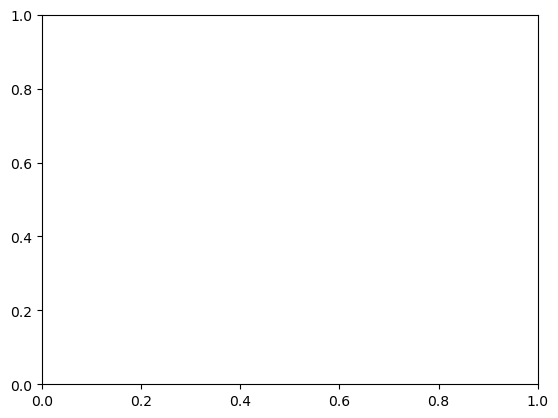

In [11]:
scatter = plt.scatter(data['z'], data['fluxdensity'] / (5 * data['dfluxdensity']), c=np.concatenate((data['fluxdensity'][:8], data['fluxdensity'][8:][::10]), axis=0), cmap='viridis', s=12)
plt.colorbar(scatter, label="Number of Cutouts")
#plt.errorbar(data['z'], data['fluxdensity'], yerr=data['dfluxdensity'], fmt='none', alpha=0.5)
plt.axhline(y=0, color='black', alpha=0.2)
plt.show()

In [6]:
sorted_data_zip = sorted(zip(data['ncutouts'],data['linelum'],data['dlinelum'],data['centfreq'],data['z'],data['fluxdensity'],data['dfluxdensity'],data['axmass']), key=lambda item: item[3])

# Unzip the sorted data back into separate lists
s_ncutouts, s_linelum, s_dlinelum, s_centfreq, s_z, s_fluxdensity, s_dfluxdensity, s_axmass = zip(*sorted_data_zip)
sorted_data = {
    'linelum': s_linelum,
    'ncutouts': s_ncutouts,
    'dlinelum': s_dlinelum,
    'fluxdensity': s_fluxdensity,
    'dfluxdensity': s_dfluxdensity,
    'z': s_z,
    'centfreq': s_centfreq,
    'axmass': s_axmass,
}

KeyError: 'z'

In [13]:
for key in sorted_data:
    sorted_data[key] = np.concatenate((sorted_data[key][:494], sorted_data[key][494:][::10]), axis=0 )

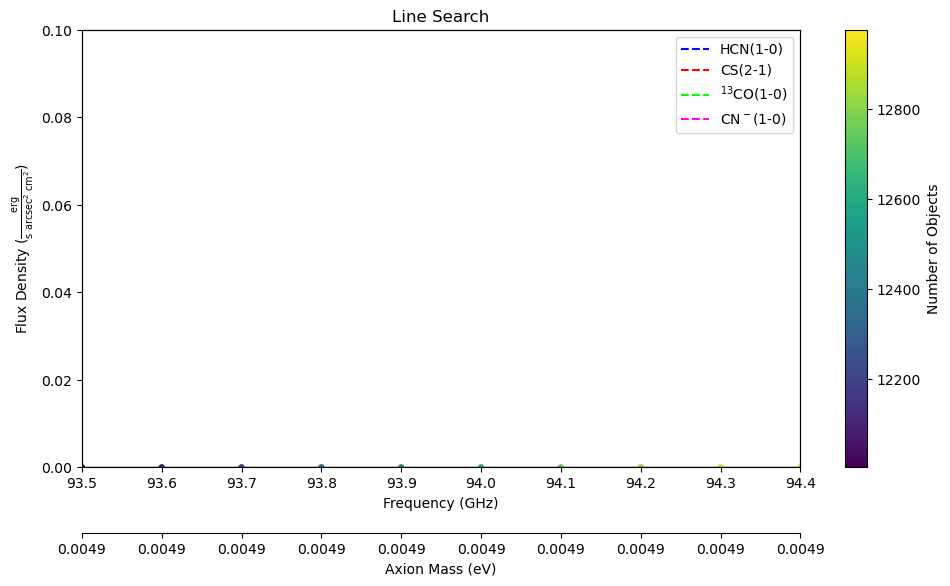

In [14]:

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(sorted_data['centfreq'], sorted_data['fluxdensity'], c=sorted_data['ncutouts'], cmap='viridis', s=12)
fig.colorbar(scatter, ax=ax, label="Number of Objects")
plt.errorbar(sorted_data['centfreq'], sorted_data['fluxdensity'], yerr=sorted_data['dfluxdensity'], fmt='none', alpha=0.5, zorder=0)
ax.axhline(y=0, color='black', alpha=0.2)

plt.axvline(x=88.63, color='blue', linestyle='--', label='HCN(1-0)')
plt.axvline(x=91.98, color='red', linestyle='--', label='CS(2-1)')
plt.axvline(x=110.2, color='lime', linestyle='--', label=r'$^{13}$CO(1-0)')
plt.axvline(x=113.49, color='magenta', linestyle='--', label=r'CN$^-$(1-0)')
plt.legend()

ax.set_xlim(data['centfreq'].min(), data['centfreq'].max())
ax.set_ylim(0, 0.1)

# make a new axis at the bottom
ax2 = ax.twiny()

ax2.spines['bottom'].set_position(('axes', -0.15))
ax2.spines['bottom'].set_visible(True)
ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')


# Match axion mass axis to redshift axis
z_ticks = ax.get_xticks()

axmass_ticks = [freq_to_axion_mass(z_val).value for z_val in z_ticks]
ax2.set_xticks(axmass_ticks)
ax2.set_xticklabels([f'{tick:.4f}' for tick in axmass_ticks]) # Format as integers for cleaner labels
ax2.set_xlim(freq_to_axion_mass(ax.get_xlim()[0]).value, freq_to_axion_mass(ax.get_xlim()[1]).value)


#ax.semilogy(sorted_data['fluxdensity']**2, (sorted_data['fluxdensity']**2) / (np.max(sorted_data['fluxdensity']**2)))

# labels
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel(r"Flux Density ($\frac{ \text{erg} }{ \text{s} \text{ arcsec}^2 \text{ cm}^2}$)")
ax.set_title("Line Search")
ax2.set_xlabel("Axion Mass (eV)")

fig.tight_layout() 
plt.savefig('PLOT_SCND.png') 
plt.show()

In [45]:
bofung = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
bofung[:8] + bofung[8:][::10]

In [55]:
bofung[10:]

[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

{'ncutouts': array([6847., 7044., 7190., ..., 6600., 6579., 6914.], shape=(6615,)),
 'linelum': array([ 8.22136583e+08,  2.55216011e+09,  4.83603725e+09, ...,
        -1.66968758e+09, -1.05885254e+10,  2.18850366e+09], shape=(6615,)),
 'dlinelum': array([8.38347375e+09, 8.21788725e+09, 8.09338729e+09, ...,
        8.61429326e+09, 8.60322494e+09, 8.17298339e+09], shape=(6615,)),
 'centfreq': array([88.71, 88.85, 88.95, ..., 88.4 , 88.1 , 87.4 ], shape=(6615,)),
 'z': array([1.957     , 1.96166667, 1.965     , ..., 1.94666667, 1.93666667,
        1.91333333], shape=(6615,)),
 'fluxdensity': array([ 1.97233722e-24,  6.12273007e-24,  1.16018390e-23, ...,
        -4.00564458e-24, -2.54022788e-23,  5.25030429e-24], shape=(6615,)),
 'dfluxdensity': array([2.01122753e-23, 1.97150269e-23, 1.94163468e-23, ...,
        2.06660202e-23, 2.06394669e-23, 1.96073009e-23], shape=(6615,)),
 'axmass': array([0.00461029, 0.00461756, 0.00462276, ..., 0.00459418, 0.00457859,
        0.00454221], shape=(6615

ValueError: x and y must be the same size

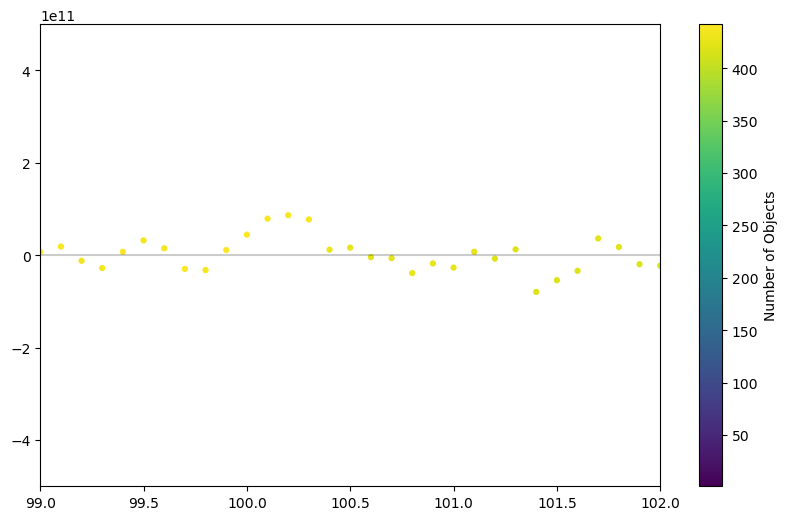

In [24]:

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(data['centfreq'], data['linelum'], c=data['ncutouts'], cmap='viridis', s=12)
fig.colorbar(scatter, ax=ax, label="Number of Objects")
#plt.errorbar(sorted_data['centfreq'], sorted_data['fluxdensity'], yerr=sorted_data['dfluxdensity'], fmt='none', alpha=0.5, zorder=0)
ax.axhline(y=0, color='black', alpha=0.2)

ax.set_xlim(99,102);
ax.set_ylim(-0.5e12,0.5e12);

ax.scatter(
    [item for item in np.arange(100.0, 101.0, 0.1) for _ in range(100)], bootstrap_linelum[0::1],
    color='red', s=12
)

# labels
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel(r"Linelum")
ax.set_title("Line Search")

fig.tight_layout() 
plt.show()

In [5]:
indices = np.where(np.round(data['centfreq'],2) == 100. )

In [31]:
#DATA_FILE = '/home/finneas/Documents/COMAP/survey_outputs/output_HETDEX/results.pkl'
DATA_FILE = '/home/finneas/Downloads/survey_outputs_260114/output_HETDEX_LAE_offs/results.pkl'
#DATA_FILE = '/home/finneas/Downloads/survey_outputs_260114/output_QSO_og_offs/results.pkl'

with open(DATA_FILE, 'rb') as f:
    data = pickle.load(f)

In [32]:
sorted_data_zip = sorted(zip(data['ncutouts'],data['linelum'],data['dlinelum'],data['centfreq']), key=lambda item: item[3])

# Unzip the sorted data back into separate lists
s_ncutouts, s_linelum, s_dlinelum, s_centfreq = zip(*sorted_data_zip)
sorted_data = {
    'linelum': s_linelum,
    'ncutouts': s_ncutouts,
    'dlinelum': s_dlinelum,
    'centfreq': s_centfreq
}

In [23]:
print(sorted_data['centfreq'][246:257])

(np.float64(112.99999999999861), np.float64(113.0999999999986), np.float64(113.1999999999986), np.float64(113.29999999999859), np.float64(113.39999999999858), np.float64(113.49999999999858), np.float64(113.59999999999857), np.float64(113.69999999999857), np.float64(113.79999999999856), np.float64(113.89999999999856), np.float64(113.99999999999855))


In [16]:
real_values = sorted_data['dlinelum'][246:257] # bad values 

In [143]:
freqs = sorted_data['centfreq'][216:227]

In [3]:
freqs = [100, 100.1, 100.2, 100.3, 100.4, 100.5, 100.6, 100.7, 100.8, 100.9, 101]

In [4]:
linelum_to_flux_Jy(13291005879.077888, 110)

NameError: name 'linelum_to_flux_Jy' is not defined

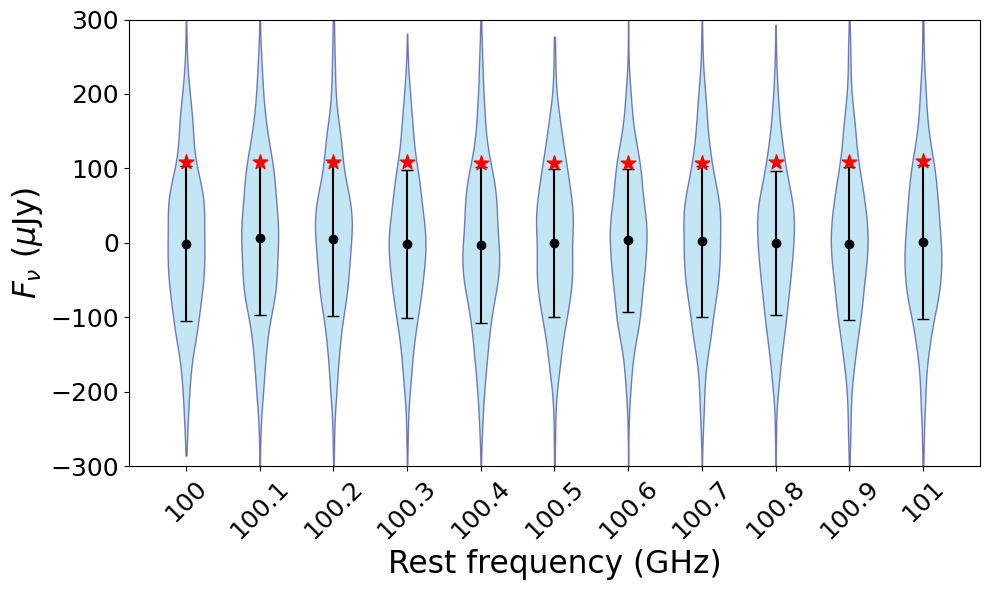

In [84]:
fig, ax = plt.subplots(figsize=(10, 6))

parts = ax.violinplot(
    all_values_uJy,
    positions=np.arange(11),
    showmeans=False,
    showmedians=False,
    showextrema=False
)

x = np.arange(11)

ax.errorbar(
    x,
    means_uJy,
    yerr=standard_deviations_uJy,
    fmt='o',
    color='black',
    capsize=4,
    label='Mean ± σ'
)

ax.scatter(
    x,
    real_values_uJy,
    color='red',
    marker='*',
    s=120,
    zorder=3,
    label='Real luminosity'
)
ax.set_ylim(-300, 300)
ax.set_xticks(x)
ax.set_xticklabels([f'{round(freqs[i], 1)}' for i in range(11)])
ax.tick_params(axis='both', labelsize=18) 
ax.set_ylabel(r"$F_\nu$ ($\mu$Jy)", fontsize=22.5)
ax.set_xlabel("Rest frequency (GHz)", fontsize=22.5)
plt.xticks(rotation=45) 
#ax.set_title('Line luminosity distributions per channel (LAEs)')
for pc in parts['bodies']:
    pc.set_facecolor('skyblue')
    pc.set_edgecolor('navy')
    pc.set_alpha(0.5)
#ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(0, 1.2), fontsize = 18)
plt.tight_layout()

plt.savefig('QSO_bootstrap_comparison_uJy_v2_cut.pdf')


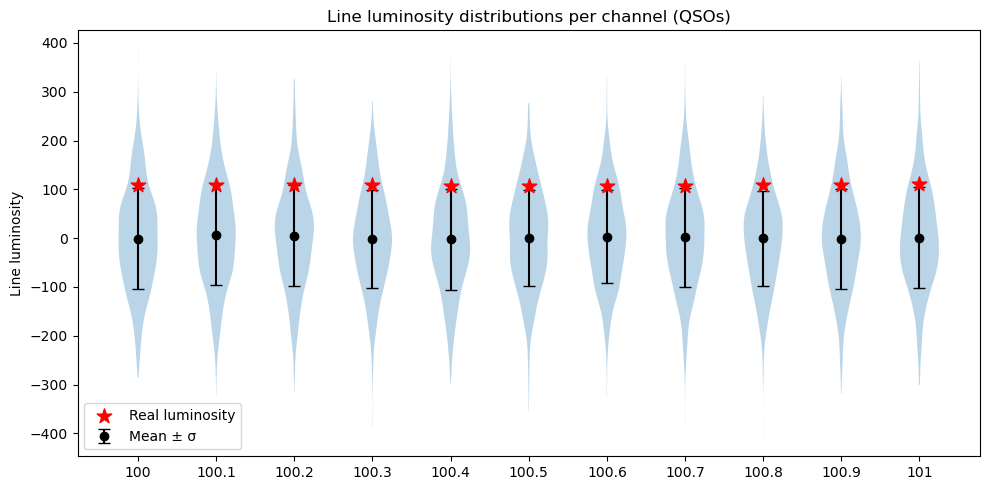

In [148]:
fig, ax = plt.subplots(figsize=(10, 5))

parts = ax.violinplot(
    all_values_uJy,
    positions=np.arange(11),
    showmeans=False,
    showmedians=False,
    showextrema=False
)

x = np.arange(11)

ax.errorbar(
    x,
    means_uJy,
    yerr=standard_deviations_uJy,
    fmt='o',
    color='black',
    capsize=4,
    label='Mean ± σ'
)

ax.scatter(
    x,
    real_values_uJy,
    color='red',
    marker='*',
    s=120,
    zorder=3,
    label='Real luminosity'
)

ax.set_xticks(x)
ax.set_xticklabels([f'{round(freqs[i], 1)}' for i in range(11)])
ax.set_ylabel('Line luminosity')
ax.set_title('Line luminosity distributions per channel (QSOs)')

ax.legend()
plt.tight_layout()
#plt.savefig('421_QSO_bootstrap_comparison.png') 
#plt.show()


In [8]:
import seaborn as sns

In [82]:
#base_folder = "/home/finneas/Downloads/output_hxrandoms/output_hxrandoms/hxtester_LAE_100.0-101.0_"
#base_folder = "/home/finneas/Downloads/output_new/QSO_100.0-101.0_"
#base_folder = "/home/finneas/Downloads/20260317_bootstrap_output/output/hxrandoms_LAE_100.0-101.0_"
base_folder = "/home/finneas/Downloads/20260317_bootstrap_output/output/uniform_QSO_100.0-101.0_"

all_values = []            # list of arrays (one per channel)
standard_deviations = []   # σ per channel
means = []                 # optional but useful
real_values = []

for i in range(11):
    folder_name = f"{base_folder}{i}"
    file_path = os.path.join(folder_name, "random_stacker_iter_output.csv")
    
    df = pd.read_csv(file_path, usecols=[0])
    values = df.iloc[:, 0].values
    
    all_values.append(values)
    standard_deviations.append(np.std(values))
    means.append(np.mean(values))

    # get real values
    file_path = os.path.join(folder_name, "actual_stack_run_x5f3_rot/data/output_values.csv")
    df = pd.read_csv(file_path, usecols=[1])
    real_values.append(df.iloc[0].values[0])

bootstrap_linelum = np.array(real_values)

In [127]:
bugg = linelum_to_flux_Jy(means[0], 110)

In [83]:
# Convert all_values
all_values_uJy = [
    linelum_to_flux_Jy(vals, freqs[i]).value
    for i, vals in enumerate(all_values)
]

# Convert means and stds
means_uJy = np.array([
    linelum_to_flux_Jy(means[i], freqs[i]).value
    for i in range(len(means))
])

standard_deviations_uJy = np.array([
    linelum_to_flux_Jy(standard_deviations[i], freqs[i]).value
    for i in range(len(standard_deviations))
])

# Convert real values
real_values_uJy = np.array([
    linelum_to_flux_Jy(real_values[i], freqs[i]).value
    for i in range(len(real_values))
])

In [78]:
real_values

[np.float64(13291005879.077888),
 np.float64(13213902585.842896),
 np.float64(13147465924.489534),
 np.float64(13077654555.442884),
 np.float64(12996149165.074894),
 np.float64(12932670780.718603),
 np.float64(12887619194.97594),
 np.float64(12876251658.367186),
 np.float64(12863264319.518902),
 np.float64(12905817413.222628),
 np.float64(12971758785.585552)]

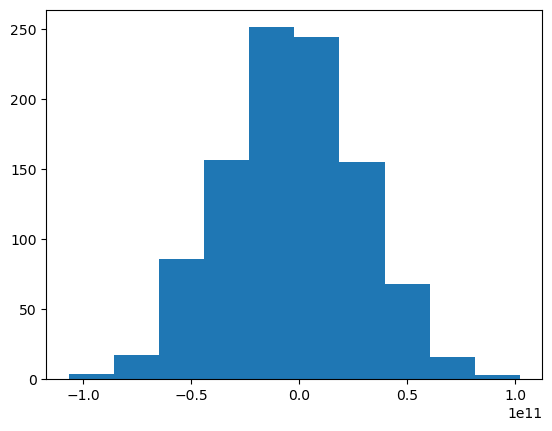

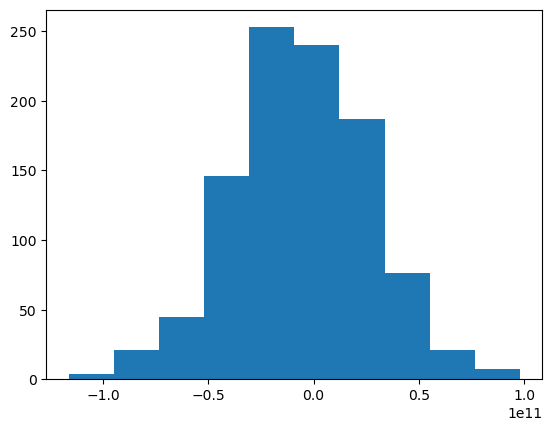

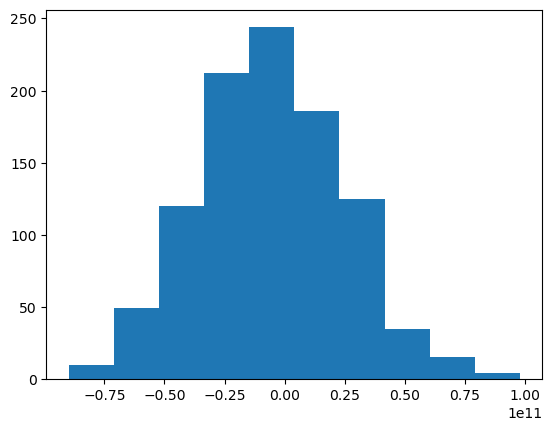

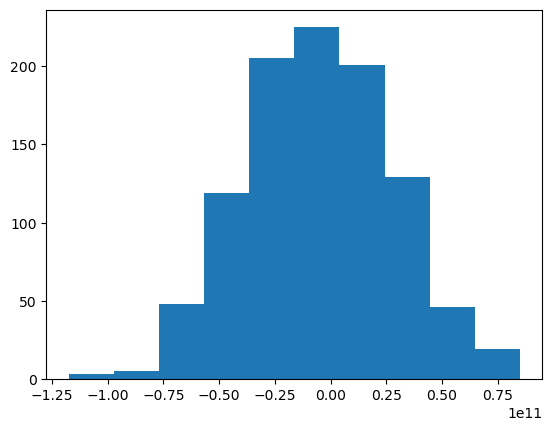

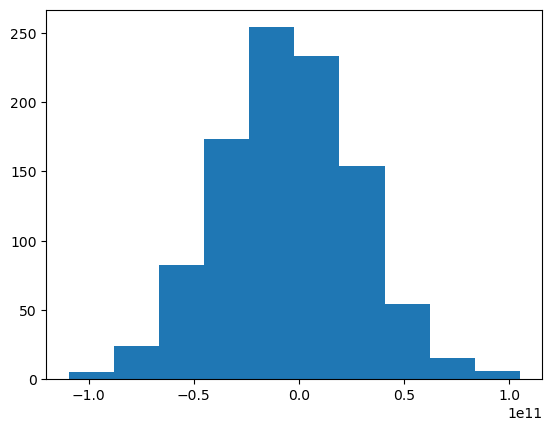

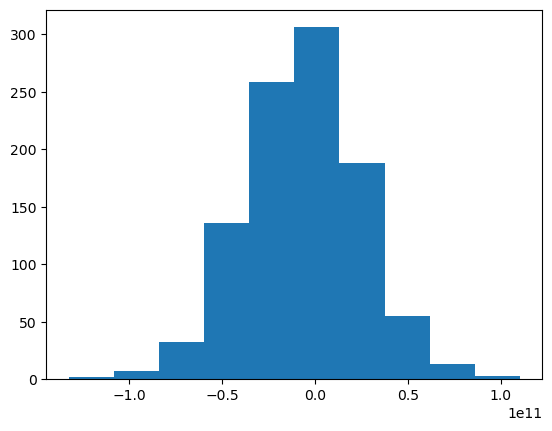

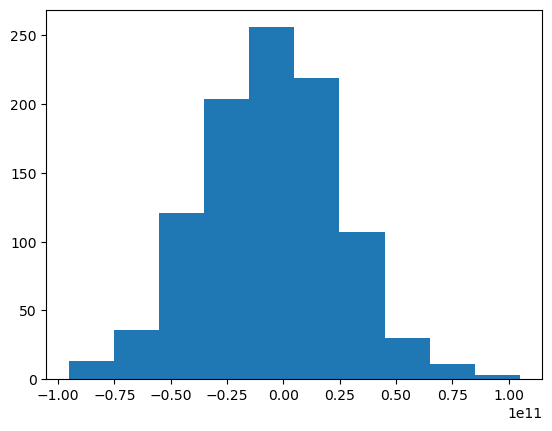

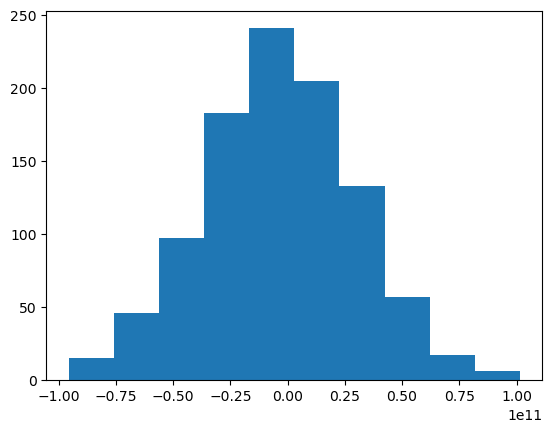

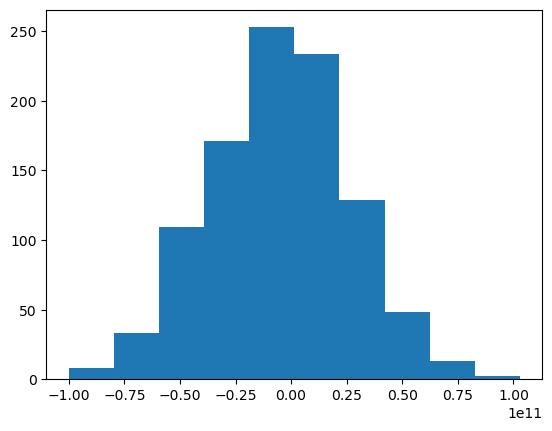

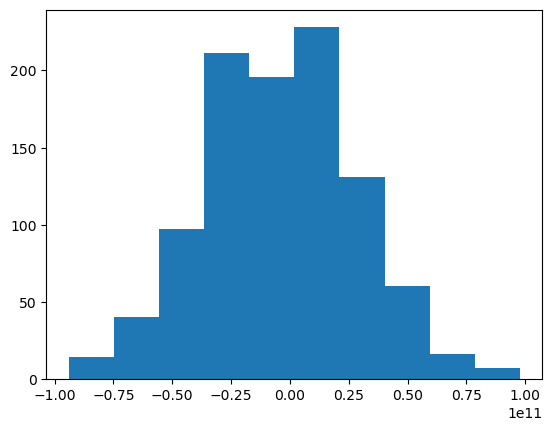

In [9]:

base_folder = "/home/finneas/Downloads/output_new/QSO_100.0-101.0_"

all_values = []
standard_deviations = []

for i in range(0, 10):
    all_values = []
    folder_name = f"{base_folder}{i}"
    file_path = os.path.join(folder_name, "random_stacker_iter_output.csv")
    
    df = pd.read_csv(file_path, usecols=[0])
    
    #all_values.extend([df.iloc[:, 0].values])
    #standard_deviations.append(df.iloc[:, 0].std());

    plt.hist(df.iloc[:, 0].values)
    plt.show()
    

bootstrap_linelum = np.array(all_values)
 

In [46]:
standard_deviations

[33514441.92133843,
 33408800.635664728,
 33910677.394659,
 34057085.609647565,
 38635156.03768474,
 37527632.07326012,
 35549785.31006896,
 35289639.29952853,
 36392332.72561351,
 39755308.60810375]

In [36]:
actual_vals = []
for i in np.arange(100., 101., 0.1):
    index = np.where(np.round(data['centfreq'],2) == i )[0]
    print(index)
    actual_vals.append(data['linelum'][index])

[245]
[254]
[]
[]
[]
[]
[]
[]
[]
[]


/tmp/ipykernel_87136/3952303105.py:3: RuntimeWarning: invalid value encountered in sqrt
  sns.heatmap(np.sqrt(cov_matrix), annot=False, fmt='g', cmap='magma')


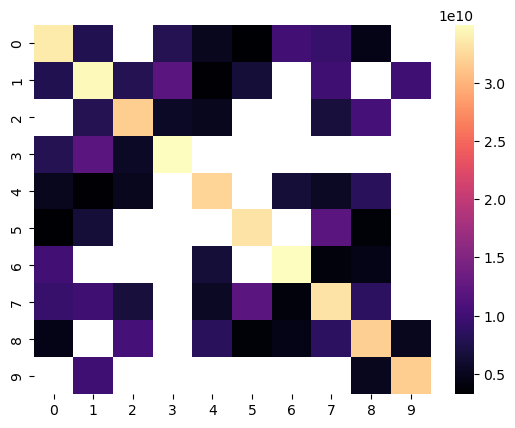

In [26]:
cov_matrix = np.cov(bootstrap_linelum)

sns.heatmap(np.sqrt(cov_matrix), annot=False, fmt='g', cmap='magma')
#plt.savefig('QSO_covariance_heatmap.png');
plt.show()

/tmp/ipykernel_7571/3411198944.py:3: RuntimeWarning: invalid value encountered in sqrt
  sns.heatmap(np.sqrt(cov_matrix), annot=False, fmt='g', cmap='magma')


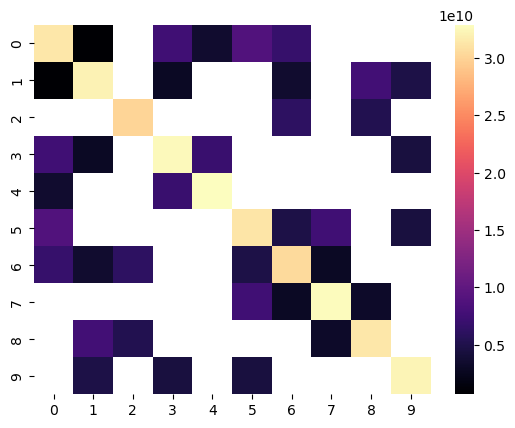

In [19]:
cov_matrix = np.cov(bootstrap_linelum)

sns.heatmap(np.sqrt(cov_matrix), annot=False, fmt='g', cmap='magma')
#plt.savefig('LAE_covariance_heatmap.png');
plt.show()

In [29]:
np.diag(np.sqrt(cov_matrix))

/tmp/ipykernel_87136/2210475040.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.diag(np.sqrt(cov_matrix))


array([8.66693265e+09, 9.18082838e+09, 8.83242882e+09, 9.16105774e+09,
       9.13699941e+09, 9.18516961e+09, 8.70833233e+09, 8.77798669e+09,
       8.78058981e+09, 9.19112550e+09])

In [17]:
bootstrap_linelum

array([], dtype=float64)